In [6]:
import pandas as pd
import seaborn as sns # not sure if needed, just import first
import matplotlib.pyplot as plt

In [ ]:
df4 = pd.read_pickle('../data/df4.pkl')

In [43]:
#df4.head(5)

In [44]:
#df4.columns

In [16]:
df4.shape

(7698511, 69)

## For Visualisation Site

Values of Current Transfer Timing Distribution by Age Group and Time of Day
- Student (Primary 1 to JC/Poly) --> 7 - 19 years old
- Adult --> 20 - 59 years old
- Senior Citizen --> 60 years and above

In [33]:
def trf_time_distribution(data):
    df = data[data['final_termination_reason'] == 'candidate_transfer'].copy()

    df['age_group'] = df['PATRON_CATG_DESC_TXT'].map({
        'Student': '7 - 19',
        'Adult': '20-59',
        'Senior Citizen': '60 and above'
    })

    df['next_entry_tm_hr'] = df['next_ENTRY_TM'].dt.hour

    result = df.pivot_table(
        index = 'age_group',
        columns = 'next_entry_tm_hr',
        aggfunc = 'size',
        fill_value = 0
    )

    return result

In [34]:
# to test
trf_time_distribution(df4) # are we going to change the dataset? since this is only a certain range

next_entry_tm_hr,0,1,5,6,7,8,9,10,11,12,...,14,15,16,17,18,19,20,21,22,23
age_group,,,,,,,,,,,,,,,,,,,,,
20-59,671,52,7325,58310,146205,167462,82154,40822,34306,34626,...,33594,36961,47332,87790,145736,102180,59498,51923,43218,21441
60 and above,100,3,5047,17736,20820,19586,17068,17462,17053,16545,...,15661,16288,19485,23277,21546,13249,9743,8228,6256,3161
7 - 19,80,8,270,16506,28437,13085,7207,4023,4568,6050,...,15119,18554,18063,17862,19627,10600,4801,3925,3291,1772


Distribution of Spatial Transfer Location Pairs

In [37]:
def trf_pair_distribution(data):
    df = data[data['final_termination_reason'] == 'candidate_transfer']

    result = df.pivot_table(
        index = 'ORIG_STATION_NAME',
        columns = 'DEST_STATION_NAME',
        aggfunc = 'size',
        fill_value = 0
    )

    # use this if want proportions instead
    # result = (
    # df.groupby(['ORIG_STATION_NAME', 'DEST_STATION_NAME'])
    #   .size()
    #   .groupby(level = 0)
    #   .apply(lambda x: x / x.sum())
    #   .reset_index(name = "value")
    # )

    return result

In [ ]:
# to test
trf_pair_distribution(df4) # are we going to change the dataset? since this is only a certain range

Temporal Transfer Pattern Distribution (y-axis: Average Transfer Time, x-axis: Hour of Day)

In [41]:
def trf_pattern_distribution(data):
    df = data[data['final_termination_reason'] == 'candidate_transfer']

    df['age_group'] = df['PATRON_CATG_DESC_TXT'].map({
        'Student': '7 - 19',
        'Adult': '20-59',
        'Senior Citizen': '60 and above'
    })

    df['next_entry_tm_hr'] = df['next_ENTRY_TM'].dt.hour

    trf_avg = (
        df.groupby('next_entry_tm_hr')['time_gap_mins']
        .mean()
        .reset_index(name = 'average_transfer_time')
    )

    plt.figure(figsize=(8, 5))

    plt.plot(trf_avg['next_entry_tm_hr'], trf_avg['average_transfer_time'], marker="o")

    plt.title("Average Transfer Time")
    plt.xlabel("Hour of Day")
    plt.ylabel("Average Transfer Time per Hour")

    plt.xticks(range(0, 24))
    plt.grid(True)

    plt.show()

C:\Users\Jeslyn\AppData\Local\Temp\ipykernel_26088\852779269.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_group'] = df['PATRON_CATG_DESC_TXT'].map({
C:\Users\Jeslyn\AppData\Local\Temp\ipykernel_26088\852779269.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['next_entry_tm_hr'] = df['next_ENTRY_TM'].dt.hour


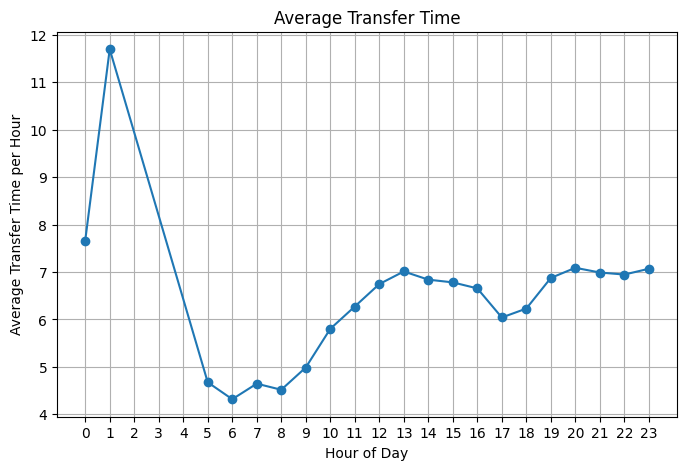

In [42]:
# to test
trf_pattern_distribution(df4) # are we going to change the dataset? since this is only a certain range

## For Geospatial Analysis (Delay Simulation Tab)

Identification of Misclassified Transfers According to our Model - Regional Hotspots (Most Affected Regions)

Identification of Misclassified Transfers According to our Model - Exact Bus Stops/Transfer Pairs

## For Policy Simulator

Input Age/Demographic, Time of Day, Tap-in and Tap-out regions, Output Recommended Transfer Time Change, Benefits and Costs